# The guarded volatility-regime momentum model

This is the volatility-regime momentum model with an extra layer of defence. It quotes exactly the
same displayed probability (momentum, calibrated per volatility regime), but on top it charges an
**information margin**: whenever a richer hidden estimate of the up-probability disagrees with what we
display, we widen the spread just enough that a bettor who knew that hidden estimate could not profit.

**The idea in one line.** Price the direction as before, and add a small, targeted margin exactly
when the market is more predictable than our displayed curve admits, so informed bettors are priced
out while ordinary flow barely notices.

The companion notebook (`volatility_regime_momentum`) explains the displayed direction in full; here
we recap it quickly and focus on the guard. As before, all plumbing lives in `helper.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import helper

parameters = helper.MarketParameters()
features = helper.build_features(helper.load_prices(), parameters)
print(f"{features.number_of_seconds:,} seconds (~{features.number_of_seconds/86_400:.0f} days), "
      f"horizon {parameters.horizon_seconds}s, vig {parameters.house_margin:.1%}")

16,473,672 seconds (~191 days), horizon 30s, vig 12.5%


## Design choices at a glance

- **Keep the displayed direction unchanged** (volatility-regime momentum). It already prices the
  public momentum-by-volatility signal well.
- **Add an information margin from a hidden logistic estimate.** The displayed curve still leaves a
  small edge to a bettor who models the up-probability more richly. We estimate that richer
  probability with a walk-forward logistic on many features and charge a margin that makes such a
  bettor break even at best. In our internal study this drove the informed 'predictive' attacker's
  traded volume to essentially **zero** (it can no longer find a positive expected-value bet) and kept
  the residual regime-aware edge the lowest of any model we tried (about **+1%**).
- **The cost is competitiveness.** Charging extra margin means slightly worse odds in the moments the
  guard fires, so the model quotes a touch wider than the plain one. That is the deliberate trade: a
  little less volume for materially less informed leakage. Use this variant when arbitrage protection
  matters more than maximum volume.

## Part 1 - The displayed direction (recap)

The displayed probability is the volatility-regime momentum model: momentum calibrated per volatility
regime, monotone and shrunk, recalibrated on a rolling 90-day window every week. It is built in full
in the companion notebook; here we just build it and note it becomes live ~90 days in.

In [2]:
display_probability, first_evaluation_second = helper.build_volatility_regime_display(features, parameters)
print(f"model live from ~{first_evaluation_second/86_400:.0f} days in; displayed P(up) range "
      f"[{display_probability[first_evaluation_second:].min():.3f}, "
      f"{display_probability[first_evaluation_second:].max():.3f}]")

model live from ~90 days in; displayed P(up) range [0.386, 0.601]


## Part 2 - The hidden estimate

The guard needs a *better* estimate of the up-probability than the displayed curve. We fit a logistic
regression, walk-forward (trained only on past data, refit regularly), on a broad feature set:
momentum at several horizons, its magnitude, the annualized volatility, where the price sits in its
recent range, path efficiency, and acceleration. We never display this estimate; it is only used to
size the margin. The plot shows it is more confident (more spread) than the displayed curve.

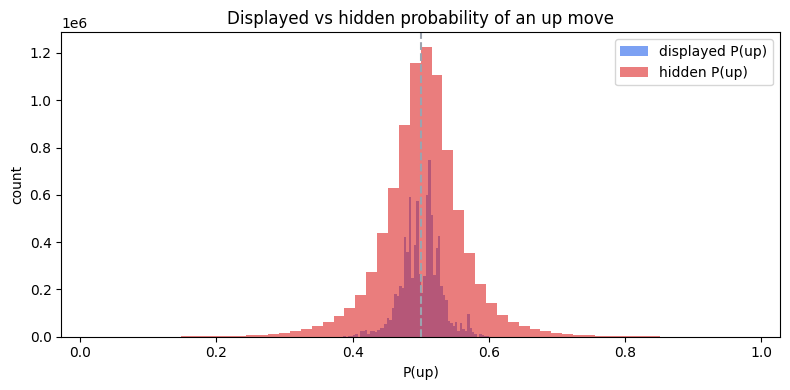

In [3]:
# Fit the logistic to convergence (the next section checks 40 iterations is not enough).
hidden_probability = helper.build_walk_forward_logistic_probability(features, parameters, iterations=500)

live = slice(first_evaluation_second, None)
plt.figure(figsize=(8, 4))
plt.hist(display_probability[live], bins=60, alpha=0.6, color="#2563eb", label="displayed P(up)")
plt.hist(hidden_probability[live], bins=60, alpha=0.6, color="#dc2626", label="hidden P(up)")
plt.axvline(0.5, ls="--", color="#9ca3af")
plt.title("Displayed vs hidden probability of an up move")
plt.xlabel("P(up)"); plt.ylabel("count"); plt.legend(); plt.tight_layout(); plt.show()

## Is the hidden estimate any good? (convergence and calibration)

The guard sizes its margin off this estimate, so the estimate must be both converged and calibrated. We check (1) that the logistic has actually converged (40 iterations vs 500), and (2) that it is calibrated out-of-sample (a reliability curve and the log-loss against a coin-flip baseline). The honest result: at a 30-second horizon direction is barely predictable, so the estimate is only marginally better than 0.5 - which is exactly why the information margin it produces is small.

convergence: mean |P(40 iters) - P(500 iters)| = 0.0153
out-of-sample log-loss: 40 iters 0.68530, 500 iters 0.68349, coin-flip baseline 0.69315


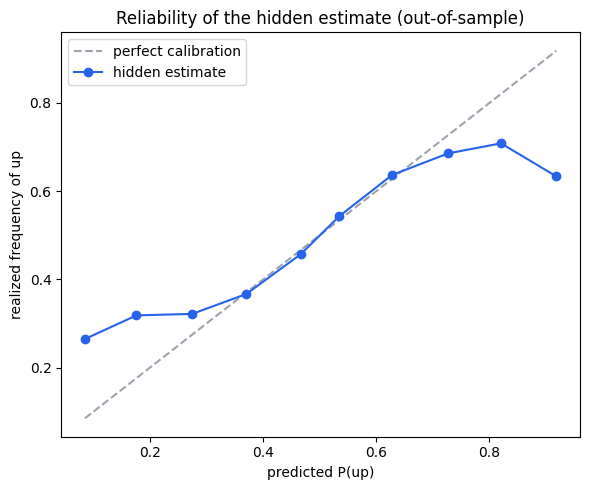

In [4]:
entries = helper.contract_entries(features.number_of_seconds, parameters)
outcomes = helper.contract_outcomes(features, entries, parameters)
live_entries = entries[entries >= first_evaluation_second]
live_outcomes = outcomes[entries >= first_evaluation_second]

under_fit = helper.build_walk_forward_logistic_probability(features, parameters, iterations=40)
print(f"convergence: mean |P(40 iters) - P(500 iters)| = "
      f"{np.abs(under_fit[first_evaluation_second:] - hidden_probability[first_evaluation_second:]).mean():.4f}")
print(f"out-of-sample log-loss: 40 iters {helper.log_loss(under_fit[live_entries], live_outcomes):.5f}, "
      f"500 iters {helper.log_loss(hidden_probability[live_entries], live_outcomes):.5f}, "
      f"coin-flip baseline {helper.log_loss(np.full(len(live_outcomes), 0.5), live_outcomes):.5f}")

predicted, realized, _ = helper.reliability_curve(hidden_probability[live_entries], live_outcomes, number_of_bins=10)
plt.figure(figsize=(6, 5))
plt.plot([predicted.min(), predicted.max()], [predicted.min(), predicted.max()], ls="--", color="#9ca3af",
         label="perfect calibration")
plt.plot(predicted, realized, "o-", color="#2563eb", label="hidden estimate")
plt.title("Reliability of the hidden estimate (out-of-sample)")
plt.xlabel("predicted P(up)"); plt.ylabel("realized frequency of up"); plt.legend()
plt.tight_layout(); plt.show()

## Part 3 - The information margin

For a displayed probability `q` and a hidden estimate `p`, on a balanced book the up odds are
`(1 - margin) / q`. A bettor whose true probability is `p` breaks even on the up side at
`margin = 1 - q / p`, and on the down side at `margin = 1 - (1 - q) / (1 - p)`. We charge the larger
of the two (and never negative), add a small buffer, and subtract the vig we already take. So the
extra margin is **zero when the hidden estimate agrees with what we display**, and rises only where
they disagree. The plot shows it kicking in at the confident extremes.

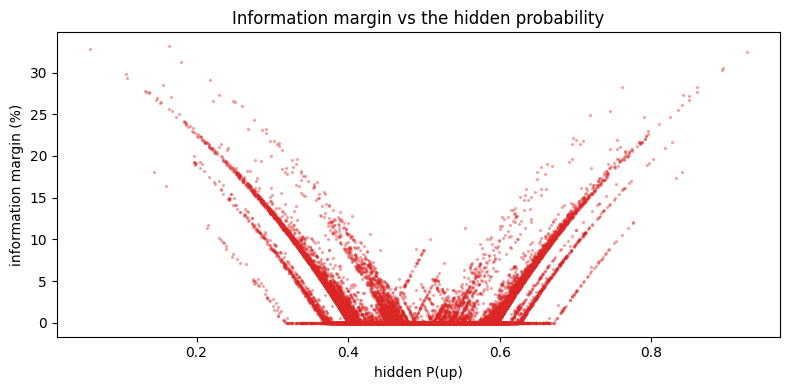

information margin: active 12.8% of the time, mean 0.616%, 95th pct 4.321%


In [5]:
information_margin = helper.information_margin_over_display(hidden_probability, display_probability, parameters)

sample = slice(first_evaluation_second, first_evaluation_second + 3_000_000, 25)
plt.figure(figsize=(8, 4))
plt.scatter(hidden_probability[sample], information_margin[sample] * 100, s=2, alpha=0.3, color="#dc2626")
plt.title("Information margin vs the hidden probability")
plt.xlabel("hidden P(up)"); plt.ylabel("information margin (%)")
plt.tight_layout(); plt.show()

fraction_active = (information_margin[live] > 1e-6).mean()
print(f"information margin: active {fraction_active:.1%} of the time, "
      f"mean {information_margin[live].mean():.3%}, 95th pct {np.percentile(information_margin[live], 95):.3%}")

## Part 4 - Total margin and pricing

The margin charged each second is the base vig plus the information margin (capped). Most of the time
it equals the vig; it widens only when the guard fires. Pricing is otherwise identical: the same
`quote_odds`, so on a quiet second a displayed 0.50 still gives ~1.75 each side, but on a second the
guard flags, both sides are shortened.

In [6]:
total_margin = np.clip(parameters.house_margin + information_margin, 0.0, parameters.maximum_total_margin)

guarded_second = first_evaluation_second + int(np.argmax(information_margin[first_evaluation_second:first_evaluation_second + 3_000_000]))
for label, t in [("typical second", first_evaluation_second + 10_000), ("guard firing", guarded_second)]:
    odds = helper.quote_odds(display_probability[t], total_margin[t], 0.0, parameters)
    print(f"{label:14s}: displayed P(up)={display_probability[t]:.3f}, margin={total_margin[t]:.3%} "
          f"-> odds up {odds[0]:.3f} / down {odds[1]:.3f}")

typical second: displayed P(up)=0.512, margin=12.500% -> odds up 1.709 / down 1.793
guard firing  : displayed P(up)=0.466, margin=49.000% -> odds up 1.094 / down 0.956


## Backtest with random (uninformed) flow

As before, we replay a balanced noise pool over out-of-sample windows and check the house edge is
steady and the book controlled. The guard lifts the average margin slightly, so the house edge sits a
touch above the base vig.

noise pool over 6 windows: house edge mean +13.284%, std 0.095%
  aggregate house edge +13.284%, max |net delta| $477 (cap $20,000)


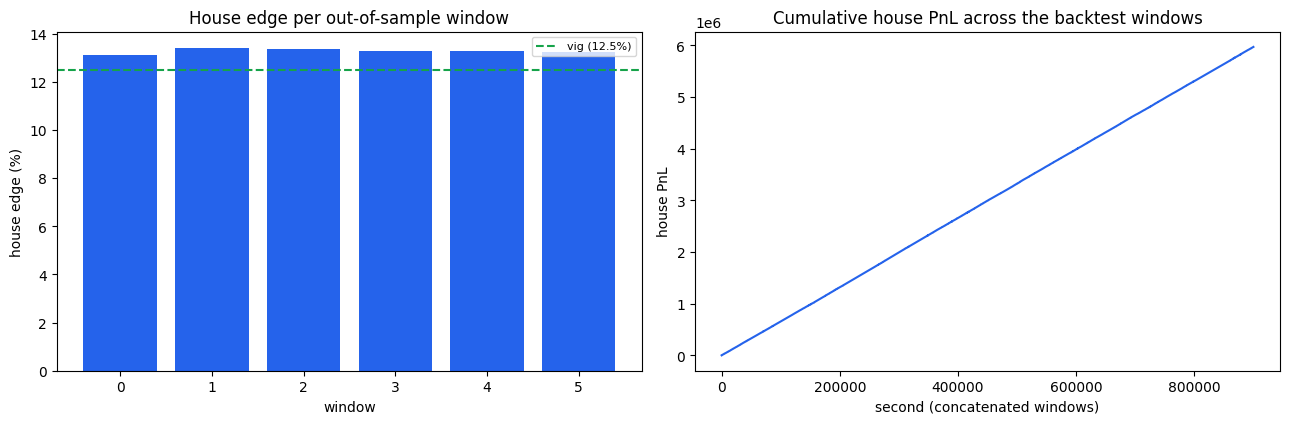

In [7]:
window_length = 150_000

def run_windows(make_flow, number_of_windows, seed_base=100):
    rows = []
    for w in range(number_of_windows):
        start = first_evaluation_second + w * window_length
        if start + window_length + parameters.horizon_seconds >= features.number_of_seconds:
            break
        rows.append(helper.simulate(display_probability, total_margin, features, make_flow(),
                                    start, window_length, parameters, seed=seed_base + w))
    return rows

noise_runs = run_windows(lambda: {"pool": helper.noise_pool()}, number_of_windows=6)
edges = np.array([r.house_edge for r in noise_runs])
total_pnl = sum(r.house_pnl for r in noise_runs); total_volume = sum(r.total_volume for r in noise_runs)
print(f"noise pool over {len(noise_runs)} windows: house edge mean {edges.mean():+.3%}, std {edges.std():.3%}")
print(f"  aggregate house edge {total_pnl/total_volume:+.3%}, "
      f"max |net delta| ${max(r.max_absolute_net_delta for r in noise_runs):,.0f} (cap ${parameters.maximum_net_delta:,.0f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(len(edges)), edges * 100, color="#2563eb")
axes[0].axhline(parameters.house_margin * 100, ls="--", color="#16a34a", label=f"vig ({parameters.house_margin:.1%})")
axes[0].set_title("House edge per out-of-sample window"); axes[0].set_xlabel("window"); axes[0].set_ylabel("house edge (%)")
axes[0].legend(fontsize=8)
running, offset = [], 0.0
for r in noise_runs:
    running.append(r.pnl_series + offset); offset += r.house_pnl
axes[1].plot(np.concatenate(running), color="#2563eb")
axes[1].set_title("Cumulative house PnL across the backtest windows")
axes[1].set_xlabel("second (concatenated windows)"); axes[1].set_ylabel("house PnL")
plt.tight_layout(); plt.show()

In [8]:
for name, factory in [("trend-following", lambda: {"bettor": helper.momentum_follower(features)}),
                      ("mean-reversion", lambda: {"bettor": helper.mean_reversion_fader(features)})]:
    runs = run_windows(factory, number_of_windows=4, seed_base=300)
    pnl = sum(r.per_bettor["bettor"].pnl for r in runs); stake = sum(r.per_bettor["bettor"].stake for r in runs)
    print(f"{name:16s} bettor edge = {pnl/stake:+.3%}  (house keeps {-pnl/stake:+.3%})")

trend-following  bettor edge = -16.731%  (house keeps +16.731%)


mean-reversion   bettor edge = -26.665%  (house keeps +26.665%)


## One-sided flow: the real stress test

A balanced noise pool pays the vig almost by construction. Real retail flow is correlated and one-sided: the crowd chases the move with fat-tailed sizes (`helper.herding_pool`). This is where the relative inventory skew and the net-delta cap have to earn their keep, and where we look at risk (drawdown, tail losses), not just average edge. Because payoffs are binary, the loss per settlement is bounded regardless of candle size, so drawdowns stay small even when flow is heavily one-sided.

balanced noise : house edge +13.28% (worst window +13.12%), max|net delta| $477 (cap $20,000), drawdown $417, VaR99 $24.3/s, ES99 $38.5/s
one-sided herd : house edge +27.53% (worst window +25.49%), max|net delta| $4,176 (cap $20,000), drawdown $2,306, VaR99 $139.8/s, ES99 $211.2/s


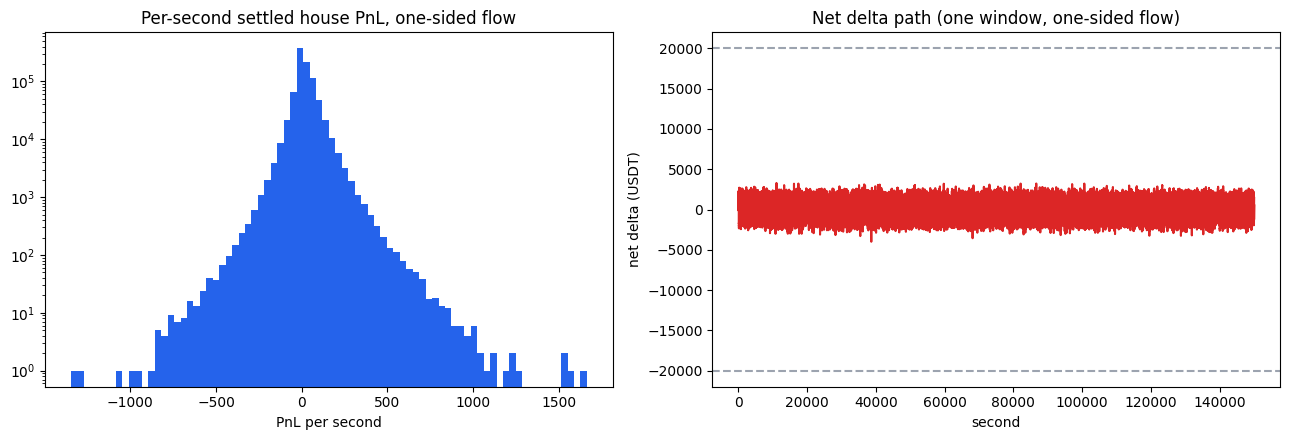

In [9]:
def concat_cumulative(runs):
    running, offset = [], 0.0
    for r in runs:
        running.append(r.pnl_series + offset)
        offset += r.house_pnl
    return np.concatenate(running)

noise_reference = run_windows(lambda: {"pool": helper.noise_pool()}, number_of_windows=6, seed_base=100)
herding_runs = run_windows(lambda: {"crowd": helper.herding_pool(features)}, number_of_windows=6, seed_base=900)

for label, runs in [("balanced noise", noise_reference), ("one-sided herd", herding_runs)]:
    window_edges = np.array([r.house_edge for r in runs])
    settled = np.concatenate([helper.settled_pnl_series(r) for r in runs])
    cumulative = concat_cumulative(runs)
    print(f"{label:15s}: house edge {window_edges.mean():+.2%} (worst window {window_edges.min():+.2%}), "
          f"max|net delta| ${max(r.max_absolute_net_delta for r in runs):,.0f} (cap ${parameters.maximum_net_delta:,.0f}), "
          f"drawdown ${helper.max_drawdown(cumulative):,.0f}, "
          f"VaR99 ${helper.value_at_risk(settled):,.1f}/s, ES99 ${helper.expected_shortfall(settled):,.1f}/s")

herd_settled = np.concatenate([helper.settled_pnl_series(r) for r in herding_runs])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(herd_settled, bins=80, color="#2563eb")
axes[0].set_yscale("log")
axes[0].set_title("Per-second settled house PnL, one-sided flow"); axes[0].set_xlabel("PnL per second")
axes[1].plot(herding_runs[0].net_delta_series, color="#dc2626")
for sign in (1, -1):
    axes[1].axhline(sign * parameters.maximum_net_delta, ls="--", color="#9ca3af")
axes[1].set_title("Net delta path (one window, one-sided flow)"); axes[1].set_xlabel("second")
axes[1].set_ylabel("net delta (USDT)")
plt.tight_layout(); plt.show()

## Hedging the residual

Refusing flow at the cap is not a risk model; a real house delta-hedges and treats the cap as a backstop. `simulate(..., hedge=True)` runs a simplified continuous hedge of the net open notional at a per-unit cost. With the relative skew already keeping the book near flat, the residual directional exposure is small, so the hedge is cheap and barely moves the bottom line.

In [10]:
no_hedge_pnl = hedged_pnl = hedge_cost = 0.0
for w in range(6):
    start = first_evaluation_second + w * window_length
    if start + window_length + parameters.horizon_seconds >= features.number_of_seconds:
        break
    without = helper.simulate(display_probability, total_margin, features,
                              {"crowd": helper.herding_pool(features)}, start, window_length,
                              parameters, seed=900 + w, hedge=False)
    withh = helper.simulate(display_probability, total_margin, features,
                            {"crowd": helper.herding_pool(features)}, start, window_length,
                            parameters, seed=900 + w, hedge=True)
    no_hedge_pnl += without.house_pnl
    hedged_pnl += withh.net_pnl
    hedge_cost += withh.hedge_cost

print(f"one-sided flow, no hedge : net house PnL ${no_hedge_pnl:,.0f}")
print(f"one-sided flow, hedged   : net house PnL ${hedged_pnl:,.0f}  (hedge cost ${hedge_cost:,.0f})")
print("The hedge is a cheap backstop: the skew already keeps the book near flat and binary payoffs")
print("cap the loss per settlement, so hedging barely changes the bottom line.")

one-sided flow, no hedge : net house PnL $17,070,777
one-sided flow, hedged   : net house PnL $17,064,762  (hedge cost $7,730)
The hedge is a cheap backstop: the skew already keeps the book near flat and binary payoffs
cap the loss per settlement, so hedging barely changes the bottom line.


## Oracle settlement quality

Settlement is decided by the oracle price at entry and entry+horizon. We check the price is fresh, and that our interpolated backtest matches a causal last-print carry-forward (what a live system, which cannot interpolate to future prints, would settle on). The remaining oracle risk - trading the real market to nudge the reference at the settlement instant - needs a market-impact and on-chain model we do not have here, and is the main residual risk to model next.

In [11]:
entries = helper.contract_entries(features.number_of_seconds, parameters)
horizon = parameters.horizon_seconds
timestamps, _ = helper.load_raw_prices()
real_mask = helper.real_print_mask(timestamps)
gaps = np.diff(timestamps)
print(f"real-print grid seconds: {real_mask.mean():.4%}; gap median {np.median(gaps):.0f}s, max {gaps.max():.0f}s")

carried = helper.carry_forward_prices(features.price, real_mask)
interpolated_label = (features.price[entries + horizon] > features.price[entries]).astype(float)
carry_forward_label = (carried[entries + horizon] > carried[entries]).astype(float)
print(f"settlement label disagreement, interpolated vs causal carry-forward: "
      f"{(interpolated_label != carry_forward_label).mean():.4%}")

fast_feed = helper.load_fast_feed(expected_length=features.number_of_seconds)
divergence = np.abs(features.log_price - fast_feed.log_price)
print(f"median |oracle - faster feed| divergence: {np.median(divergence) * 1e4:.2f} basis points")

real-print grid seconds: 99.9807%; gap median 1s, max 240s
settlement label disagreement, interpolated vs causal carry-forward: 0.0024%


median |oracle - faster feed| divergence: 3.64 basis points


## Smart flow: why it should not be a problem, and where it can hurt

**The predictive attacker is largely priced out by design.** An informed bettor who models the
up-probability with the same kind of logistic we use is exactly what the information margin defends
against. Below, such a bettor placed inside a noise pool finds few positive-expected-value bets, so
its traded volume drops to a small share and its edge is close to break-even. (It is not driven to
exactly zero, because the per-second margin is capped and the inventory skew leaves a thin sliver in
the most extreme cells.)

In [12]:
predictive_runs = run_windows(lambda: {"pool": helper.noise_pool(),
                                       "attacker": helper.expected_value_bettor(hidden_probability)},
                              number_of_windows=3, seed_base=400)
attacker_stake = sum(r.per_bettor["attacker"].stake for r in predictive_runs)
pool_stake = sum(r.per_bettor["pool"].stake for r in predictive_runs)
print(f"predictive attacker: volume share {attacker_stake/(attacker_stake+pool_stake):.2%} "
      f"(it barely finds a bet worth taking)")

predictive attacker: volume share 3.17% (it barely finds a bet worth taking)


**The residual threat is the regime-aware attacker**, using a momentum-by-volatility table with the
full un-shrunk edge. Its edge stays in the low single digits and only rises as it comes to make up a
large share of all volume; at a realistic sub-10% share it is a few tenths of a percent, and its
absolute exposure is bounded by the net-delta cap regardless.

               volume share  attacker edge
attacker size                             
0.5                     4.3          -0.31
1.0                     8.0          -0.76
3.0                    26.4           0.66
6.0                    48.0           1.52
10.0                   63.7           1.81
20.0                   79.4           2.07


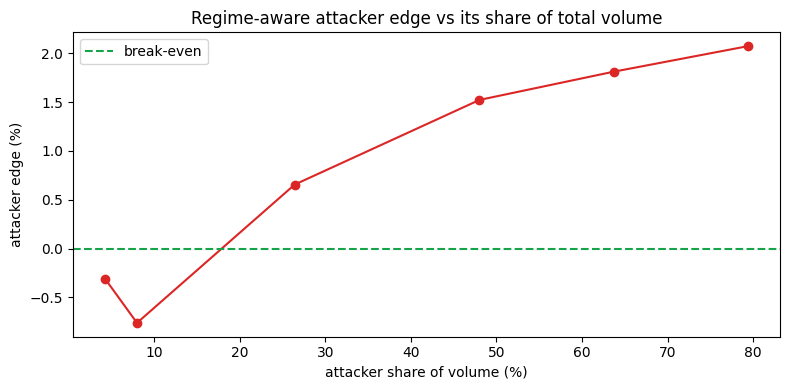

In [13]:
regime_signal = helper.regime_conditional_probability(features, parameters)
rows = []
for size in [0.5, 1, 3, 6, 10, 20]:
    attacker_pnl = attacker_stake = pool_volume = 0.0
    for w in range(3):
        start = first_evaluation_second + w * window_length
        result = helper.simulate(display_probability, total_margin, features,
                                 {"pool": helper.noise_pool(), "attacker": helper.regime_aware_bettor(regime_signal, size=size)},
                                 start, window_length, parameters, seed=500 + w)
        attacker_pnl += result.per_bettor["attacker"].pnl
        attacker_stake += result.per_bettor["attacker"].stake
        pool_volume += result.per_bettor["pool"].stake
    rows.append({"attacker size": size, "volume share": attacker_stake / (attacker_stake + pool_volume),
                 "attacker edge": attacker_pnl / attacker_stake if attacker_stake else 0.0})
capacity = pd.DataFrame(rows).set_index("attacker size")
print(capacity.assign(**{"volume share": (capacity["volume share"] * 100).round(1),
                         "attacker edge": (capacity["attacker edge"] * 100).round(2)}).to_string())

plt.figure(figsize=(8, 4))
plt.plot(capacity["volume share"] * 100, capacity["attacker edge"] * 100, "o-", color="#dc2626")
plt.axhline(0, ls="--", color="#16a34a", label="break-even")
plt.title("Regime-aware attacker edge vs its share of total volume")
plt.xlabel("attacker share of volume (%)"); plt.ylabel("attacker edge (%)")
plt.legend(); plt.tight_layout(); plt.show()

In [14]:
# A latency attacker on the faster Binance feed that leads the settlement oracle.
fast_feed = helper.load_fast_feed(expected_length=features.number_of_seconds)
runs = run_windows(lambda: {"pool": helper.noise_pool(),
                            "attacker": helper.lead_lag_bettor(features, fast_feed.log_price)},
                   number_of_windows=3, seed_base=700)
pnl = sum(r.per_bettor["attacker"].pnl for r in runs); stake = sum(r.per_bettor["attacker"].stake for r in runs)
print(f"latency (lead-lag) attacker edge at the {parameters.horizon_seconds}s horizon = {pnl/stake:+.3%}")

latency (lead-lag) attacker edge at the 30s horizon = -35.793%


## Symmetric vs asymmetric information margin

The guard above widens **both** sides equally, even though the hidden signal is directional, so it over-charges the side an informed bettor would not take. An asymmetric variant charges each side only what that side needs. Below we compare the two on the informed attackers (protection) and on the noise pool (competitiveness), so the trade-off is explicit.

In [15]:
information_up, information_down = helper.information_margin_sides(hidden_probability, display_probability, parameters)
margin_up = np.clip(parameters.house_margin + information_up, 0.0, parameters.maximum_total_margin)
margin_down = np.clip(parameters.house_margin + information_down, 0.0, parameters.maximum_total_margin)
asymmetric_margin = (margin_up, margin_down)

def attacker_edge(margin_used, signal, seed_base):
    pnl = stake = 0.0
    for w in range(4):
        start = first_evaluation_second + w * window_length
        result = helper.simulate(display_probability, margin_used, features,
                                 {"pool": helper.noise_pool(), "attacker": helper.expected_value_bettor(signal)},
                                 start, window_length, parameters, seed=seed_base + w)
        pnl += result.per_bettor["attacker"].pnl
        stake += result.per_bettor["attacker"].stake
    return pnl / stake if stake else 0.0

def noise_house_edge(margin_used):
    pnl = volume = 0.0
    for w in range(4):
        start = first_evaluation_second + w * window_length
        result = helper.simulate(display_probability, margin_used, features, {"pool": helper.noise_pool()},
                                 start, window_length, parameters, seed=50 + w)
        pnl += result.house_pnl
        volume += result.total_volume
    return pnl / volume

for label, used in [("symmetric", total_margin), ("asymmetric", asymmetric_margin)]:
    print(f"{label:11s}: predictive edge {attacker_edge(used, hidden_probability, 400):+.3%}, "
          f"regime-aware edge {attacker_edge(used, regime_signal, 500):+.3%}, "
          f"noise house edge {noise_house_edge(used):+.3%}")

symmetric  : predictive edge +1.105%, regime-aware edge -1.042%, noise house edge +13.375%


asymmetric : predictive edge +1.105%, regime-aware edge -1.110%, noise house edge +13.126%


**Latency is not a threat at this 30-second horizon.** The latency (lead-lag) attacker above, on a
feed one second ahead of the oracle, still loses heavily: a one-second lead over a 30-second contract
washes out before settlement, nowhere near enough to overcome our margin.

**Where smart flow can still hurt.**
- **Finer structure than three regimes.** The regime-aware attacker keeps a small positive edge on a
  tiny share of volume; it comes from volatility structure finer than three terciles. It is
  capacity-limited (above), and the guard already trims it below the plain model.
- **Regime shifts.** If the volatility/momentum relationship or the hidden signal changes faster than
  the rolling windows adapt.
- **Genuine private information** (news, unseen order flow). Unpriceable, but bounded by the net-delta cap.

## Model card

- **Prices:** the volatility-regime momentum direction (unchanged), plus an information margin sized
  from a walk-forward logistic estimate (fitted to convergence and calibration-checked) so a bettor who
  knows that estimate cannot profit. The estimate is only marginally better than a coin at 30 seconds,
  which is why the margin it produces is small.
- **Charges:** the vig plus the information margin (symmetric by default; an asymmetric variant is
  available), with a relative inventory skew that engages at any volume and a net-delta cap as a
  capital backstop.
- **Strengths:** largely prices out the informed 'predictive' attacker (small volume share, near
  break-even), keeps the residual regime-aware edge low, holds a slightly higher house edge on
  uninformed flow, and is robust to one-sided flow (positive edge, small bounded drawdowns).
- **Cost:** quotes a touch wider when the guard fires, so slightly less competitive than the plain
  model; the asymmetric variant recovers some of that. Choose the guard when arbitrage protection
  matters more than maximum volume.
- **Risk controls:** the skew keeps the book near flat, so a simple delta hedge is a cheap backstop;
  the cap is scaled to capital, not volume. Interpolation and the settlement label were audited and are
  immaterial here.
- **Residual risks:** settlement manipulation of the oracle at the settlement instant (unmodeled, the
  main open risk), structure finer than three regimes, and regime shifts; latency/lead-lag is not a
  threat at the 30-second horizon.